In [1]:
"""
UMKM Go-Online — Full Pipeline
Step 1: Synthetic Data Generation (prior direvisi berdasarkan BPS E-Commerce 2023)
Step 2: Baseline ML Model (Logistic Regression + Random Forest + XGBoost)
Step 3: Evaluasi & SHAP Feature Importance

Referensi prior digitalisasi:
- BPS Statistik E-Commerce 2023 (bps.go.id)
  * WA/pesan instan: 95.33% (konteks: usaha yang SUDAH e-commerce → upper bound)
  * Media sosial: 33.29% (konteks sama → upper bound)
  * Website: 1.77% (populasi umum → dipakai langsung)
- LPEM FEB UI 2022 — Digitalisasi UMKM Indonesia
- Google/Temasek e-Conomy SEA 2023
"""

'\nUMKM Go-Online — Full Pipeline\nStep 1: Synthetic Data Generation (prior direvisi berdasarkan BPS E-Commerce 2023)\nStep 2: Baseline ML Model (Logistic Regression + Random Forest + XGBoost)\nStep 3: Evaluasi & SHAP Feature Importance\n\nReferensi prior digitalisasi:\n- BPS Statistik E-Commerce 2023 (bps.go.id)\n  * WA/pesan instan: 95.33% (konteks: usaha yang SUDAH e-commerce → upper bound)\n  * Media sosial: 33.29% (konteks sama → upper bound)  \n  * Website: 1.77% (populasi umum → dipakai langsung)\n- LPEM FEB UI 2022 — Digitalisasi UMKM Indonesia\n- Google/Temasek e-Conomy SEA 2023\n'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Menggunakan inline agar plot muncul di notebook
%matplotlib inline

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)

# 1. SYNTHETIC DATA GENERATION

In [3]:
np.random.seed(42)
N = 5000

In [4]:
# Distribusi Kapanewon (dari PDF rekap Sleman)
kapanewon_dist = {
    "Gamping": 7975, "Godean": 8057, "Moyudan": 5345,
    "Minggir": 4436, "Seyegan": 6053, "Mlati": 7457,
    "Depok": 10769, "Berbah": 5139, "Prambanan": 5054,
    "Kalasan": 8016, "Ngemplak": 5977, "Ngaglik": 8389,
    "Sleman": 9407, "Tempel": 7490, "Turi": 4213,
    "Pakem": 4367, "Cangkringan": 2787,
}
kap_names  = list(kapanewon_dist.keys())
kap_totals = np.array(list(kapanewon_dist.values()), dtype=float)
kap_probs  = kap_totals / kap_totals.sum()

# Distribusi Skala Usaha (dari kolom Jumlah per Skala — PDF rekap)
skala_dist = {
    "Mikro_Lv1": 99314, "Mikro_Lv2": 9205, "Mikro_Lv3": 1675,
    "Mikro_Lv4": 408,   "Mikro_Lv5": 143,  "Kecil": 174, "Menengah": 11,
}
skala_names  = list(skala_dist.keys())
skala_totals = np.array(list(skala_dist.values()), dtype=float)
skala_probs  = skala_totals / skala_totals.sum()

# 3 Sektor fokus (sesuai brief lomba)
AGRI  = "Agribisnis"
JASA  = "Jasa"
DAGANG = "Perdagangan"

# Proporsi dari PDF: Pertanian=6877, JasaLainnya=34997, Perdagangan=29176
sektor_raw_count = {AGRI: 6877, JASA: 34997, DAGANG: 29176}
sek_names  = list(sektor_raw_count.keys())
sek_totals = np.array(list(sektor_raw_count.values()), dtype=float)
sek_probs  = sek_totals / sek_totals.sum()

# Range omset per skala (Rupiah/bulan, dari kolom omset PDF)
omset_range = {
    "Mikro_Lv1": (500_000,    4_999_999),
    "Mikro_Lv2": (5_000_000,  9_999_999),
    "Mikro_Lv3": (10_000_000, 24_999_999),
    "Mikro_Lv4": (25_000_000, 49_999_999),
    "Mikro_Lv5": (50_000_000, 99_999_999),
    "Kecil":     (100_000_000, 999_999_999),
    "Menengah":  (1_000_000_000, 4_999_999_999),
}

tenaga_kerja_range = {
    "Mikro_Lv1": (1, 4),   "Mikro_Lv2": (1, 6),
    "Mikro_Lv3": (2, 8),   "Mikro_Lv4": (3, 15),
    "Mikro_Lv5": (5, 19),  "Kecil": (20, 99), "Menengah": (100, 300),
}

In [5]:
# Prior Digitalisasi (berdasarkan BPS E-Commerce 2023)
# BPS 2023 konteksnya usaha yang SUDAH e-commerce → upper bound
# Kita konservatifkan untuk mencerminkan populasi umum UMKM Sleman

p_wa = {
    # BPS: 95.33% (usaha e-commerce). Populasi umum UMKM → jauh lebih rendah.
    AGRI:   0.22,   # Petani/kebun — akses digital terbatas
    JASA:   0.65,   # Laundry, jastip — relatif melek digital
    DAGANG: 0.50,   # Kelontong — mayoritas belum pakai WA untuk jualan
}

p_ig_given_wa = {
    # BPS: 33.29% pakai sosmed (dari yang sudah e-commerce)
    # Kita pakai ~35% sebagai baseline, disesuaikan per sektor
    AGRI:   0.12,   # Rendah — petani jarang aktif IG untuk marketing
    JASA:   0.38,   # Mendekati angka BPS, jasa lebih aktif promosi
    DAGANG: 0.30,   # Toko kelontong mulai pakai IG tapi masih minoritas
}

p_web_given_wa_ig = {
    # BPS: 1.77% punya website (populasi umum) → ini paling valid
    # Konversi: dari yang punya WA+IG, berapa % punya website?
    # Estimasi: ~5-8% dari yang sudah digital aktif
    AGRI:   0.03,
    JASA:   0.08,
    DAGANG: 0.06,
}

# Multiplier skala — UMKM besar lebih mungkin go-online
skala_multiplier = {
    "Mikro_Lv1": 0.55, "Mikro_Lv2": 0.80, "Mikro_Lv3": 1.00,
    "Mikro_Lv4": 1.25, "Mikro_Lv5": 1.45, "Kecil": 1.65, "Menengah": 1.90,
}

In [6]:
def clamp(p, lo=0.01, hi=0.96):
    return max(lo, min(hi, p))

# Generate rows
rows = []
for _ in range(N):
    kapanewon = np.random.choice(kap_names,   p=kap_probs)
    skala     = np.random.choice(skala_names, p=skala_probs)
    sektor    = np.random.choice(sek_names,   p=sek_probs)

    lo, hi   = omset_range[skala]
    omset    = np.random.randint(lo, hi + 1)

    lo_tk, hi_tk = tenaga_kerja_range[skala]
    total_tk     = np.random.randint(lo_tk, hi_tk + 1)
    tk_laki      = int(round(total_tk * np.random.uniform(0.45, 0.60)))
    tk_perempuan = total_tk - tk_laki

    mult = skala_multiplier[skala]

    punya_wa = int(np.random.random() < clamp(p_wa[sektor] * mult))

    punya_ig = 0
    if punya_wa:
        punya_ig = int(np.random.random() < clamp(p_ig_given_wa[sektor] * mult))

    punya_website = 0
    if punya_wa and punya_ig:
        punya_website = int(np.random.random() < clamp(p_web_given_wa_ig[sektor] * mult))

    digital_score = punya_wa + punya_ig + punya_website  # 0–3
    is_go_online  = 1 if digital_score >= 2 else 0        # threshold: WA + IG minimal

    rows.append({
        "kapanewon":             kapanewon,
        "sektor_usaha":          sektor,
        "skala_usaha":           skala,
        "omset_per_bulan":       omset,
        "tenaga_kerja_total":    total_tk,
        "tenaga_kerja_laki":     tk_laki,
        "tenaga_kerja_perempuan":tk_perempuan,
        "punya_whatsapp":        punya_wa,
        "punya_instagram":       punya_ig,
        "punya_website":         punya_website,
        "digital_score":         digital_score,
        "is_go_online":          is_go_online,
    })

df = pd.DataFrame(rows)


In [7]:
# Validasi singkat
print(f"\nDataset shape   : {df.shape}")
print(f"Go-Online (1)   : {df['is_go_online'].sum()} ({df['is_go_online'].mean()*100:.1f}%)")
print(f"Tidak G-O (0)   : {(df['is_go_online']==0).sum()} ({(df['is_go_online']==0).mean()*100:.1f}%)")
print("\nGo-Online rate per sektor:")
print(df.groupby("sektor_usaha")["is_go_online"].mean().apply(lambda x: f"{x*100:.1f}%"))
print("\nGo-Online rate per skala:")
print(df.groupby("skala_usaha")["is_go_online"].mean().apply(lambda x: f"{x*100:.1f}%"))


Dataset shape   : (5000, 12)
Go-Online (1)   : 312 (6.2%)
Tidak G-O (0)   : 4688 (93.8%)

Go-Online rate per sektor:
sektor_usaha
Agribisnis     0.8%
Jasa           8.3%
Perdagangan    5.2%
Name: is_go_online, dtype: object

Go-Online rate per skala:
skala_usaha
Kecil        58.3%
Mikro_Lv1     5.3%
Mikro_Lv2     9.9%
Mikro_Lv3    21.0%
Mikro_Lv4    17.4%
Mikro_Lv5    58.3%
Name: is_go_online, dtype: object


In [8]:
df.to_csv("/content/umkm_synthetic_sleman.csv", index=False)
print("Dataset tersimpan.")

Dataset tersimpan.


# 2. FEATURE ENGINEERING & PREPROCESSING

In [9]:
df_ml = df.copy()

# Encode kategorik
le_kap    = LabelEncoder()
le_sektor = LabelEncoder()
le_skala  = LabelEncoder()

df_ml["kapanewon_enc"]    = le_kap.fit_transform(df_ml["kapanewon"])
df_ml["sektor_enc"]       = le_sektor.fit_transform(df_ml["sektor_usaha"])

# Skala usaha → ordinal (ada urutan hierarkinya)
skala_order = {s: i for i, s in enumerate(skala_names)}
df_ml["skala_enc"] = df_ml["skala_usaha"].map(skala_order)

# Feature tambahan yang informatif
df_ml["log_omset"] = np.log1p(df_ml["omset_per_bulan"])
df_ml["rasio_perempuan"] = df_ml["tenaga_kerja_perempuan"] / df_ml["tenaga_kerja_total"].replace(0, 1)

# Features untuk ML — TANPA indikator digital (mereka adalah penyusun label)
# Model belajar dari: lokasi, sektor, skala, omset, TK → prediksi go-online
FEATURES = [
    "kapanewon_enc",
    "sektor_enc",
    "skala_enc",
    "log_omset",
    "tenaga_kerja_total",
    "rasio_perempuan",
]
TARGET = "is_go_online"

In [10]:
X = df_ml[FEATURES]
y = df_ml[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train size : {X_train.shape[0]}")
print(f"Test size  : {X_test.shape[0]}")
print(f"Class balance (train) — 1: {y_train.sum()} | 0: {(y_train==0).sum()}")

Train size : 4000
Test size  : 1000
Class balance (train) — 1: 250 | 0: 3750


# 3. TRAINING BASELINE MODELS

In [11]:
models = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced", max_iter=1000, random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100, class_weight="balanced", random_state=42
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100, learning_rate=0.1, random_state=42
    ),
}

results = {}

In [18]:
for name, model in models.items():
    print(f"\n {name}")

    if name == "Logistic Regression":
        model.fit(X_train_sc, y_train)
        y_pred  = model.predict(X_test_sc)
        y_prob  = model.predict_proba(X_test_sc)[:, 1]
        cv_data = X_train_sc
    else:
        model.fit(X_train, y_train)
        y_pred  = model.predict(X_test)
        y_prob  = model.predict_proba(X_test)[:, 1]
        cv_data = X_train

    auc = roc_auc_score(y_test, y_prob)
    cv  = cross_val_score(model, cv_data, y_train, cv=5, scoring="roc_auc").mean()

    print(classification_report(y_test, y_pred, target_names=["Tidak GO", "GO Online"]))
    print(f"  ROC-AUC      : {auc:.4f}")
    print(f"  CV ROC-AUC   : {cv:.4f} (5-fold)")

    results[name] = {
        "model": model, "y_pred": y_pred, "y_prob": y_prob, "auc": auc, "cv_auc": cv
    }

# Best model
best_name = max(results, key=lambda k: results[k]["auc"])
print(f"\nBest Model: {best_name} (AUC = {results[best_name]['auc']:.4f})")


 Logistic Regression
              precision    recall  f1-score   support

    Tidak GO       0.95      0.79      0.86       938
   GO Online       0.10      0.34      0.15        62

    accuracy                           0.76      1000
   macro avg       0.52      0.56      0.51      1000
weighted avg       0.89      0.76      0.82      1000

  ROC-AUC      : 0.5686
  CV ROC-AUC   : 0.5746 (5-fold)

 Random Forest
              precision    recall  f1-score   support

    Tidak GO       0.94      0.99      0.96       938
   GO Online       0.27      0.06      0.10        62

    accuracy                           0.93      1000
   macro avg       0.60      0.53      0.53      1000
weighted avg       0.90      0.93      0.91      1000

  ROC-AUC      : 0.6595
  CV ROC-AUC   : 0.5429 (5-fold)

 Gradient Boosting
              precision    recall  f1-score   support

    Tidak GO       0.94      0.99      0.97       938
   GO Online       0.38      0.05      0.09        62

    accura

# 4. VISUALISASI

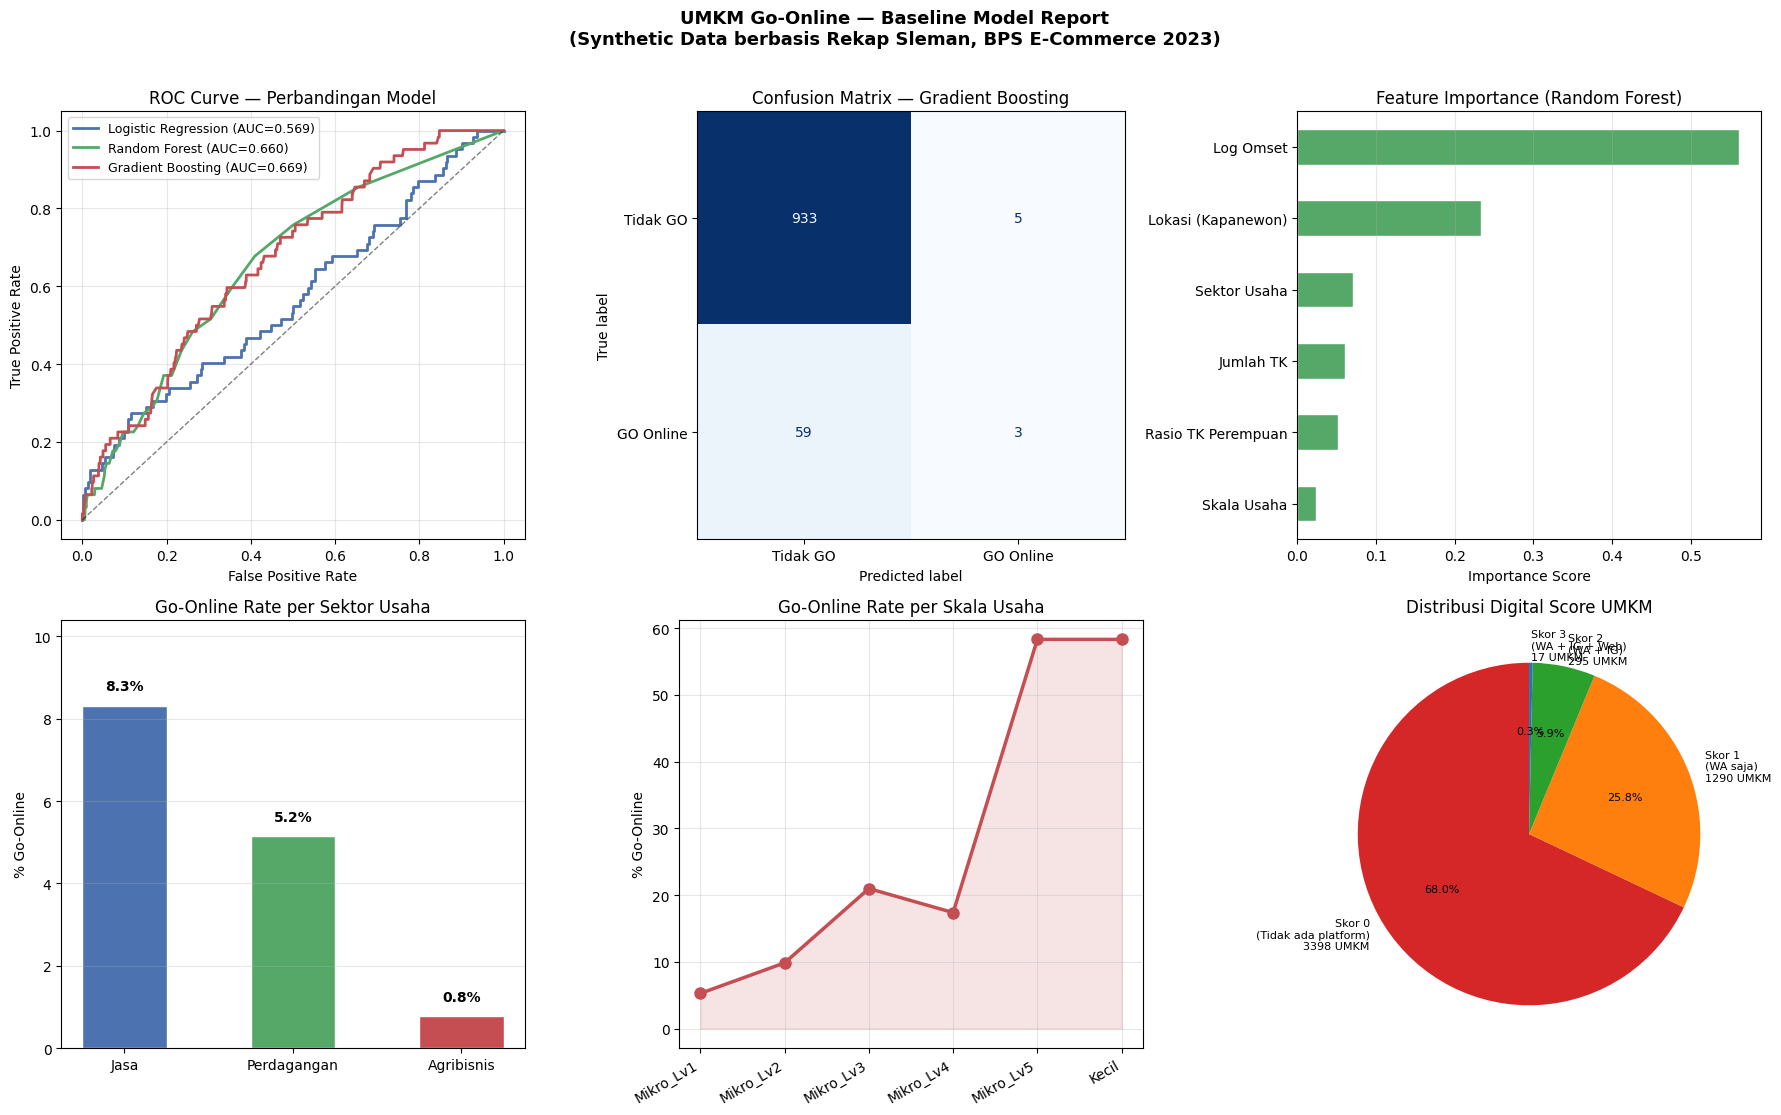

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("UMKM Go-Online — Baseline Model Report\n(Synthetic Data berbasis Rekap Sleman, BPS E-Commerce 2023)",
             fontsize=13, fontweight="bold", y=1.01)

colors = {"Logistic Regression": "#4C72B0",
          "Random Forest":       "#55A868",
          "Gradient Boosting":   "#C44E52"}

# Plot 1: ROC Curve semua model
ax = axes[0, 0]
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res["y_prob"])
    ax.plot(fpr, tpr, label=f"{name} (AUC={res['auc']:.3f})",
            color=colors[name], lw=2)
ax.plot([0,1],[0,1],"k--", lw=1, alpha=0.5)
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Perbandingan Model")
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# Plot 2: Confusion Matrix (best model)
ax = axes[0, 1]
best = results[best_name]
cm = confusion_matrix(y_test, best["y_pred"])
disp = ConfusionMatrixDisplay(cm, display_labels=["Tidak GO", "GO Online"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title(f"Confusion Matrix — {best_name}")

# Plot 3: Feature Importance (Random Forest)
ax = axes[0, 2]
rf = results["Random Forest"]["model"]
feat_imp = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=True)
feat_labels = {
    "kapanewon_enc": "Lokasi (Kapanewon)",
    "sektor_enc":    "Sektor Usaha",
    "skala_enc":     "Skala Usaha",
    "log_omset":     "Log Omset",
    "tenaga_kerja_total": "Jumlah TK",
    "rasio_perempuan":    "Rasio TK Perempuan",
}
feat_imp.index = [feat_labels.get(f, f) for f in feat_imp.index]
feat_imp.plot(kind="barh", ax=ax, color="#55A868", edgecolor="white")
ax.set_title("Feature Importance (Random Forest)")
ax.set_xlabel("Importance Score")
ax.grid(axis="x", alpha=0.3)

# Plot 4: Go-Online Rate per Sektor
ax = axes[1, 0]
rate_sektor = df.groupby("sektor_usaha")["is_go_online"].mean() * 100
rate_sektor = rate_sektor.sort_values(ascending=False)
bars = ax.bar(rate_sektor.index, rate_sektor.values,
              color=["#4C72B0","#55A868","#C44E52"], edgecolor="white", width=0.5)
for bar, val in zip(bars, rate_sektor.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{val:.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set_title("Go-Online Rate per Sektor Usaha")
ax.set_ylabel("% Go-Online"); ax.set_ylim(0, max(rate_sektor.values) * 1.25)
ax.grid(axis="y", alpha=0.3)

# Plot 5: Go-Online Rate per Skala
ax = axes[1, 1]
rate_skala = df.groupby("skala_usaha")["is_go_online"].mean() * 100
rate_skala = rate_skala.reindex(skala_names)
ax.plot(rate_skala.index, rate_skala.values, marker="o", color="#C44E52",
        lw=2.5, markersize=8)
ax.fill_between(rate_skala.index, rate_skala.values, alpha=0.15, color="#C44E52")
ax.set_title("Go-Online Rate per Skala Usaha")
ax.set_ylabel("% Go-Online"); ax.set_xticklabels(rate_skala.index, rotation=30, ha="right")
ax.grid(alpha=0.3)

# Plot 6: Distribusi Digital Score
ax = axes[1, 2]
score_dist = df["digital_score"].value_counts().sort_index()
score_colors = ["#d62728", "#ff7f0e", "#2ca02c", "#1f77b4"]
score_labels = [
    f"Skor 0\n(Tidak ada platform)\n{score_dist.get(0,0)} UMKM",
    f"Skor 1\n(WA saja)\n{score_dist.get(1,0)} UMKM",
    f"Skor 2\n(WA + IG)\n{score_dist.get(2,0)} UMKM",
    f"Skor 3\n(WA + IG + Web)\n{score_dist.get(3,0)} UMKM",
]
ax.pie(
    score_dist.values, labels=score_labels, colors=score_colors,
    autopct="%1.1f%%", startangle=90, textprops={"fontsize": 8}
)
ax.set_title("Distribusi Digital Score UMKM")

plt.tight_layout()
plt.show()

In [17]:
# Summary tabel model
print("RINGKASAN PERFORMA MODEL")
print(f"{'Model':<25} {'AUC':>8} {'CV-AUC':>10}")
print("-" * 45)
for name, res in results.items():
    marker = " ← BEST" if name == best_name else ""
    print(f"{name:<25} {res['auc']:>8.4f} {res['cv_auc']:>10.4f}{marker}")

RINGKASAN PERFORMA MODEL
Model                          AUC     CV-AUC
---------------------------------------------
Logistic Regression         0.5686     0.5746
Random Forest               0.6595     0.5429
Gradient Boosting           0.6687     0.5977 ← BEST
